In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [22]:
df = pd.read_csv("/content/drive/MyDrive/Assignment 3 /AllProductReviews (2).csv")

# Keep required columns
df = df[['ReviewBody', 'ReviewStar']]

# Rename columns
df = df.rename(columns={
    'ReviewBody': 'reviewText',
    'ReviewStar': 'overall'
})

# Remove missing values
df = df.dropna()

print(df.head())

                                          reviewText  overall
0  No doubt it has a great bass and to a great ex...        3
1  This  earphones are unreliable, i bought it be...        1
2  i bought itfor 999,I purchased it second time,...        4
3  Its sound quality is adorable. overall it was ...        1
4  Its Awesome... Good sound quality & 8-9 hrs ba...        5


In [4]:
def convert_sentiment(star):
    if star <= 2:
        return 0   # Negative
    elif star == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

df['label'] = df['overall'].apply(convert_sentiment)

print(df[['reviewText', 'label']].head())

                                          reviewText  label
0  No doubt it has a great bass and to a great ex...      1
1  This  earphones are unreliable, i bought it be...      0
2  i bought itfor 999,I purchased it second time,...      2
3  Its sound quality is adorable. overall it was ...      0
4  Its Awesome... Good sound quality & 8-9 hrs ba...      2


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['reviewText'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [6]:
vectorizer = TfidfVectorizer(
    max_features=10000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [24]:
y_pred = rf_model.predict(X_test_tfidf)

In [10]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8075313807531381
Precision: 0.7658843085608646
Recall: 0.8075313807531381
F1 Score: 0.7643044460728771

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.71      0.76       686
           1       0.39      0.02      0.04       301
           2       0.81      0.97      0.88      1881

    accuracy                           0.81      2868
   macro avg       0.67      0.57      0.56      2868
weighted avg       0.77      0.81      0.76      2868



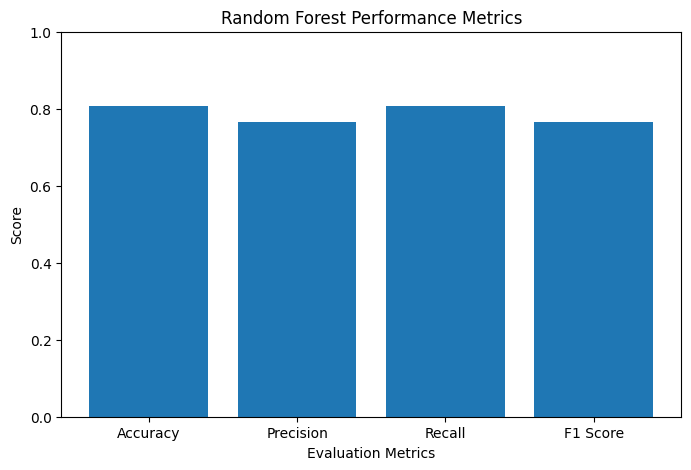

In [11]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy, precision, recall, f1]

plt.figure(figsize=(8,5))

plt.bar(metrics, scores)

plt.ylim(0, 1)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Random Forest Performance Metrics")

plt.show()

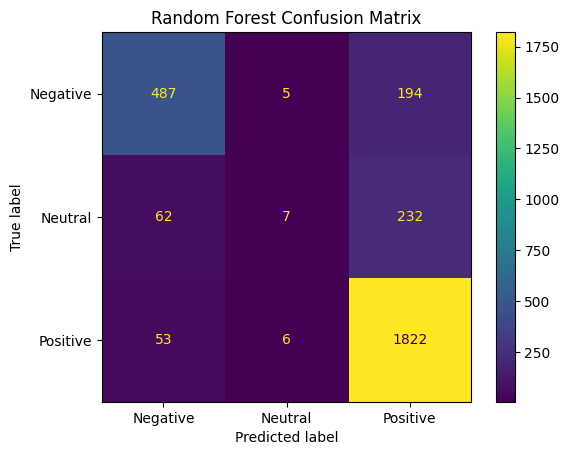

In [12]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Neutral', 'Positive']
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()